# YOLO

Este notebook abordará a utilização e o ajuste fino (fine-tuning) da arquitetura **You Only Look Once (YOLO)**, especificamente implementada pela biblioteca **Ultralytics**. O YOLO é um detector de objetos em tempo real que reformulou a detecção ao tratar o problema como uma regressão única. O fine-tuning é uma técnica crucial no Deep Learning que permite adaptar um modelo pré-treinado em um *dataset* vasto (como COCO) para uma tarefa específica com um *dataset* menor e mais especializado, aproveitando o conhecimento hierárquico já aprendido pelo modelo base.

A biblioteca **Ultralytics YOLO** fornece uma interface de alto nível e eficiente para diversas versões do YOLO (YOLOv8, YOLOv5, etc.), tornando a inferência e o treinamento acessíveis. A filosofia é focar na usabilidade sem sacrificar a performance.

Para começar, demonstraremos a inferência básica, que é o processo de usar um modelo treinado para fazer previsões em novos dados. Utilizaremos um modelo pré-treinado em um *dataset* padrão para a detecção de objetos.

In [ ]:
# Instalação da biblioteca ultralytics. Pode ser necessário reiniciar o runtime.
#!pip install ultralytics # instalado no requirements.txt

In [1]:
import os
import random
import glob
from IPython.display import display
from PIL import Image
from ultralytics import YOLO

import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/gilcesarf/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.49


In [13]:
import torch

# Selecciona o dispositivo com prioridade: CUDA > MPS > CPU
device = torch.device(
    'cuda' if torch.cuda.is_available() # GPU
    else 'mps' if torch.backends.mps.is_available() # MPS (Mac Silicon)
    else 'cpu' # CPU
)
print(f"Usando o dispositivo: {device}")

Usando o dispositivo: mps


## Inferência

O processo de inferência com o YOLO da Ultralytics é notavelmente simples. Basta carregar um modelo pré-treinado, como o `yolov8n.pt` (a versão *nano* do YOLOv8, que oferece um bom equilíbrio entre velocidade e precisão) e chamar o método `predict` com a fonte de dados desejada.

### Inferência em Imagens

A inferência em uma imagem envolve o carregamento do arquivo e a obtenção das caixas delimitadoras (*bounding boxes*), classes e pontuações de confiança para os objetos detectados.

In [14]:
model = YOLO('yolov8n.pt')
model.to(device)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

Executando a inferência em uma imagem de exemplo (pode ser um URL ou caminho local). O Ultralytics baixa automaticamente os pesos do modelo na primeira execução. O modo `save=True` salva a imagem com as detecções desenhadas. Usaremos uma imagem de exemplo que o próprio Ultralytics pode acessar.

É importante notar que o argumento `source` aceita caminhos para arquivos locais, URLs e até mesmo index de câmeras.

In [16]:
results = model.predict(source='https://ultralytics.com/images/bus.jpg', save=False, conf=0.25, device=device)


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /Users/gilcesarf/git/repositories/imd/imd1114-202601/deep-learning/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 16.9ms
Speed: 2.4ms preprocess, 16.9ms inference, 4.5ms postprocess per image at shape (1, 3, 640, 480)


In [4]:
for r in results:
    r.show()

In [5]:
# 'results' é uma lista de objetos Results, um para cada fonte de entrada (no caso, apenas um).
for r in results:
    print(f"Número de objetos detectados: {len(r.boxes)}")
    for box in r.boxes:
        print(f"Coordenadas: {box.xyxy.cpu().numpy()[0]} - Confiança: {box.conf.cpu().numpy()[0]:.2f} - Classe: {box.cls.cpu().numpy()[0]:.0f}")

Número de objetos detectados: 6
Coordenadas: [     22.871      231.28         805      756.84] - Confiança: 0.87 - Classe: 5
Coordenadas: [      48.55      398.55      245.35       902.7] - Confiança: 0.87 - Classe: 0
Coordenadas: [     669.47      392.19      809.72      877.04] - Confiança: 0.85 - Classe: 0
Coordenadas: [     221.52       405.8      344.97      857.54] - Confiança: 0.83 - Classe: 0
Coordenadas: [          0      550.53      63.007      873.44] - Confiança: 0.26 - Classe: 0
Coordenadas: [   0.058161      254.46      32.557      324.87] - Confiança: 0.26 - Classe: 11


## Fine-tuning

O **Fine-tuning** é a parte central da transferência de aprendizado (*Transfer Learning*). A premissa é que os pesos de um modelo treinado em um *dataset* genérico (como o COCO, que contém 80 classes gerais) já capturaram características de baixo nível (bordas, texturas, formas) e de alto nível (partes de objetos) que são úteis para tarefas correlatas.

Ao realizar o *fine-tuning*, carregamos esses pesos pré-treinados e continuamos o treinamento em nosso *dataset* específico, geralmente com uma **taxa de aprendizado** (*learning rate*) muito menor, para evitar a destruição das representações úteis aprendidas previamente.

### Carregamento do Dataset no Padrão YOLO

O Ultralytics YOLO espera que o *dataset* esteja em um formato específico. O padrão de estrutura de diretórios é importante:

```

dataset_name/
│
├── images/
│   ├── train/
│   ├── val/
│   └── test/        # opcional
│
└── labels/
    ├── train/
    ├── val/
    └── test/        # opcional
```

O arquivo de configuração `YAML` deve conter os caminhos para as pastas, o número de classes (`nc`) e os nomes das classes (`names`).

Utilizaremos um pequeno *dataset* público para fins didáticos. O dataset de **frutas (Fruits-360)**, adaptado para o padrão YOLO, é um bom exemplo.

In [10]:
DATASET_DIR = "data/fruit-detection/Fruits-detection/"

In [ ]:
#!curl -L -o data/fruit-detection.zip https://www.kaggle.com/api/v1/datasets/download/lakshaytyagi01/fruit-detection
#!unzip -q data/fruit-detection.zip -d data/fruit-detection

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  500M  100  500M    0     0  5140k      0  0:01:39  0:01:39 --:--:-- 5001k  500M   12 63.2M    0     0  5335k      0  0:01:36  0:00:12  0:01:24 5490k500M   18 94.6M    0     0  5293k      0  0:01:36  0:00:18  0:01:18 5143k  500M   29  149M    0     0  5260k      0  0:01:37  0:00:29  0:01:08 5566k 500M   30  154M    0     0  5260k      0  0:01:37  0:00:30  0:01:07 5634k  500M   48  243M    0     0  5295k      0  0:01:36  0:00:47  0:00:49 5517k66  500M   66  335M    0     0  5189k      0  0:01:38  0:01:06  0:00:32 5078k500M   74  373M    0     0  5149k      0  0:01:39  0:01:14  0:00:25 4789k  500M   75  378M    0     0  5157k      0  0:01:39  0:01:15  0:00:24 5015k0k      0  0:01:39  0:01:20  0:00:19 4887k  500M   88  441M    0     0  5134k      0  0:

In [ ]:
# names:
# - Apple
# - Banana
# - Grape
# - Orange
# - Pineapple
# - Watermelon
# nc: 6
# test: test/images
# train: train/images
# val: valid/images

###  Execução do Fine-tuning

O fine-tuning é realizado utilizando o comando `model.train()`. É essencial carregar um modelo pré-treinado (como o `yolov8n.pt`) para inicializar os pesos.

Os principais hiperparâmetros a serem configurados são:
* `data`: O caminho para o arquivo YAML de configuração do *dataset*.
* `epochs`: O número de épocas de treinamento. Para fine-tuning, geralmente são necessárias poucas épocas (10-50).
* `imgsz`: O tamanho da imagem de entrada.
* `batch`: O tamanho do *batch*. Deve ser ajustado à memória da GPU.

O processo de treinamento irá ajustar os pesos do modelo pré-treinado para as classes e características específicas do novo *dataset*.

In [17]:
# Carrega o modelo pré-treinado novamente
model = YOLO('yolov8n.pt')
model.to(device)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [18]:
results = model.train(
    data=os.path.join(DATASET_DIR, "data.yaml"),
    epochs=3,
    imgsz=640,
    batch=32,
    name='yolov8n_fruits_finetune',
    device=device
)

print("Fine-tuning concluído. O modelo treinado (best.pt) foi salvo em 'runs/detect/yolov8n_fruits_finetune/weights'.")

engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/fruit-detection/Fruits-detection/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_fruits_finetune-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretra

## Análise e Inferência com o Modelo Ajustado

Após o treinamento, o modelo com o melhor desempenho (*best.pt*) é salvo. É fundamental avaliar o modelo ajustado para garantir que ele aprendeu a detectar as novas classes de interesse de forma eficaz.

O principal indicador de desempenho em detecção de objetos é o **mAP (mean Average Precision)**, que agrega as curvas de Precision-Recall para cada classe.

$$
mAP = \frac{1}{N_{cl}} \sum_{i=1}^{N_{cl}} AP_i
$$

Onde $N_{cl}$ é o número de classes e $AP_i$ é a Precisão Média para a classe $i$. O Ultralytics geralmente reporta o $mAP50$ (mAP com IoU de 0.5) e o $mAP50-95$ (média do mAP em vários *thresholds* de IoU de 0.5 a 0.95).

In [20]:
# Carregando o modelo ajustado (best.pt)
tuned_model = YOLO('runs/detect/yolov8n_fruits_finetune-4/weights/best.pt')

In [21]:
ex = [
    "data/fruit-detection/Fruits-detection/valid/images/8f1d18e7da5441f2_jpg.rf.b4125eafdef809e68807d0beca36ec99.jpg",
    "data/fruit-detection/Fruits-detection/valid/images/13d28cd060404722_jpg.rf.984c09010138baaf3ae012b8e564e82c.jpg"
]

Arquivo: data/fruit-detection/Fruits-detection/valid/images/8f1d18e7da5441f2_jpg.rf.b4125eafdef809e68807d0beca36ec99.jpg


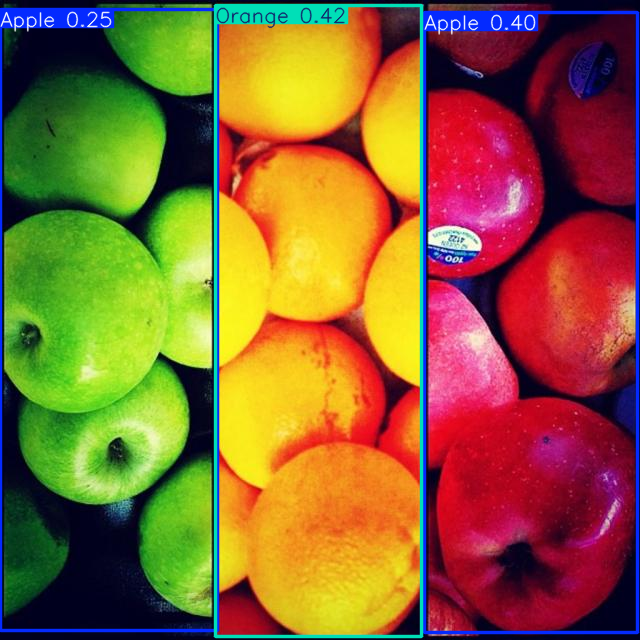

Arquivo: data/fruit-detection/Fruits-detection/valid/images/13d28cd060404722_jpg.rf.984c09010138baaf3ae012b8e564e82c.jpg


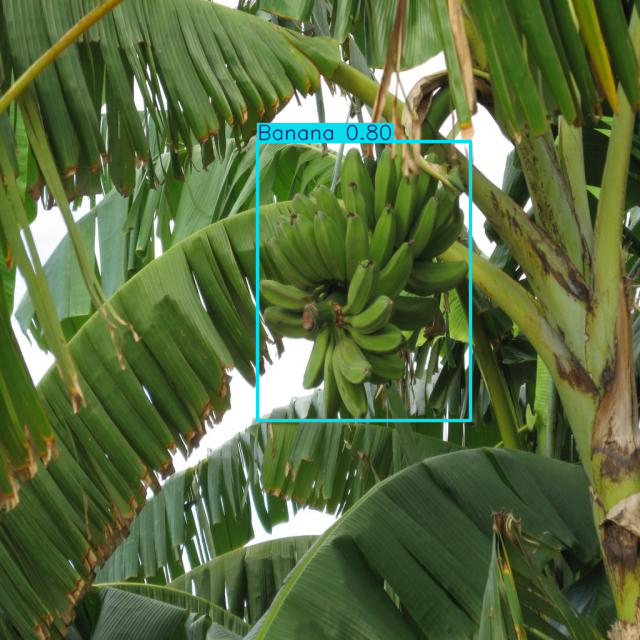

In [22]:
# n = 4
# val_dir = os.path.join(DATASET_DIR, "valid/images")
# image_paths = glob.glob(val_dir + "/*.jpg")
# sample_paths = random.sample(image_paths, n)

for img_path in ex:
    results = model.predict(source=img_path, conf=0.25, verbose=False)
    annotated_array = results[0].plot()  # BGR
    annotated_img = Image.fromarray(annotated_array[:, :, ::-1])  # agora RGB
    
    print(f"Arquivo: {img_path}")
    display(annotated_img)